# 댓글 감성 분석 EDA 보고서

**목표**: 유튜버 이탈 예측 모델에서 댓글 감성 분석 결과를 피처로 활용할 수 있는지 탐색  
**데이터**: `youtube_model_db.comments_table` — 226개 채널, 2,161개 영상, 79,937개 댓글  
**감성 레이블**: 0 = Negative, 1 = Positive (이진 분류)

---

## 분석 흐름

1. 기본 통계 및 전체 분포
2. 이탈(Churn) vs 유지(Retain) 감성 차이
3. 샘플링 편향 검증 (인기순 수집)
4. video_index별 감성 추이
5. `is_churned` 기준 Engagement 지표 비교
6. 결론 및 향후 방향

## 0. 환경 설정

In [1]:
import sys
sys.path.insert(0, '.')
from dotenv import load_dotenv
load_dotenv('.env')

import db_utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import text
from scipy.stats import mannwhitneyu, chi2_contingency
from IPython.display import Image, display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

engine = db_utils.get_engine()
db_utils.test_connection()

DB 연결 성공!
접속 방식 : 직접 연결
host     : 127.0.0.1:3306
database : youtube_model_db


---
## 1. 기본 통계 및 전체 분포

### 1-1. 데이터 개요

In [2]:
df = pd.read_sql(
    sql=text("SELECT band, channel_identifier, video_id, video_index, "
             "sentiment_label, like_count, comment_timestamp FROM comments_table"),
    con=engine
)
df['sentiment_label'] = pd.to_numeric(df['sentiment_label'], errors='coerce')
df['sentiment'] = df['sentiment_label'].map({0: 'Negative', 1: 'Positive'})
df['year'] = pd.to_datetime(df['comment_timestamp']).dt.year

print(f"전체 댓글 수    : {len(df):,}")
print(f"채널 수         : {df['channel_identifier'].nunique()}")
print(f"영상 수         : {df['video_id'].nunique()}")
print(f"band 종류       : {sorted(df['band'].unique())}")
print(f"댓글 기간       : {df['comment_timestamp'].min()} ~ {df['comment_timestamp'].max()}")
print()
print(df['sentiment'].value_counts())
print(f"\n전체 긍정 비율  : {df['sentiment_label'].mean()*100:.1f}%")

전체 댓글 수    : 79,937
채널 수         : 226
영상 수         : 2161
band 종류       : ['A', 'B', 'C', 'D']
댓글 기간       : 2017-05-19 00:00:00 ~ 2026-05-19 02:04:00

sentiment
Positive    42298
Negative    37639
Name: count, dtype: int64

전체 긍정 비율  : 52.9%


### 1-2. 분포 시각화

- 전체 긍정 비율: **52.9%** (Positive 42,298 / Negative 37,639)
- Band D가 가장 긍정적(54.5%), Band A가 가장 중립에 가까움(50.0%)
- 연도별로는 2017~2019년 긍정 비율이 높았다가 점차 50%대로 수렴
- like_count 구간별 긍정 비율은 52~54%로 큰 차이 없음

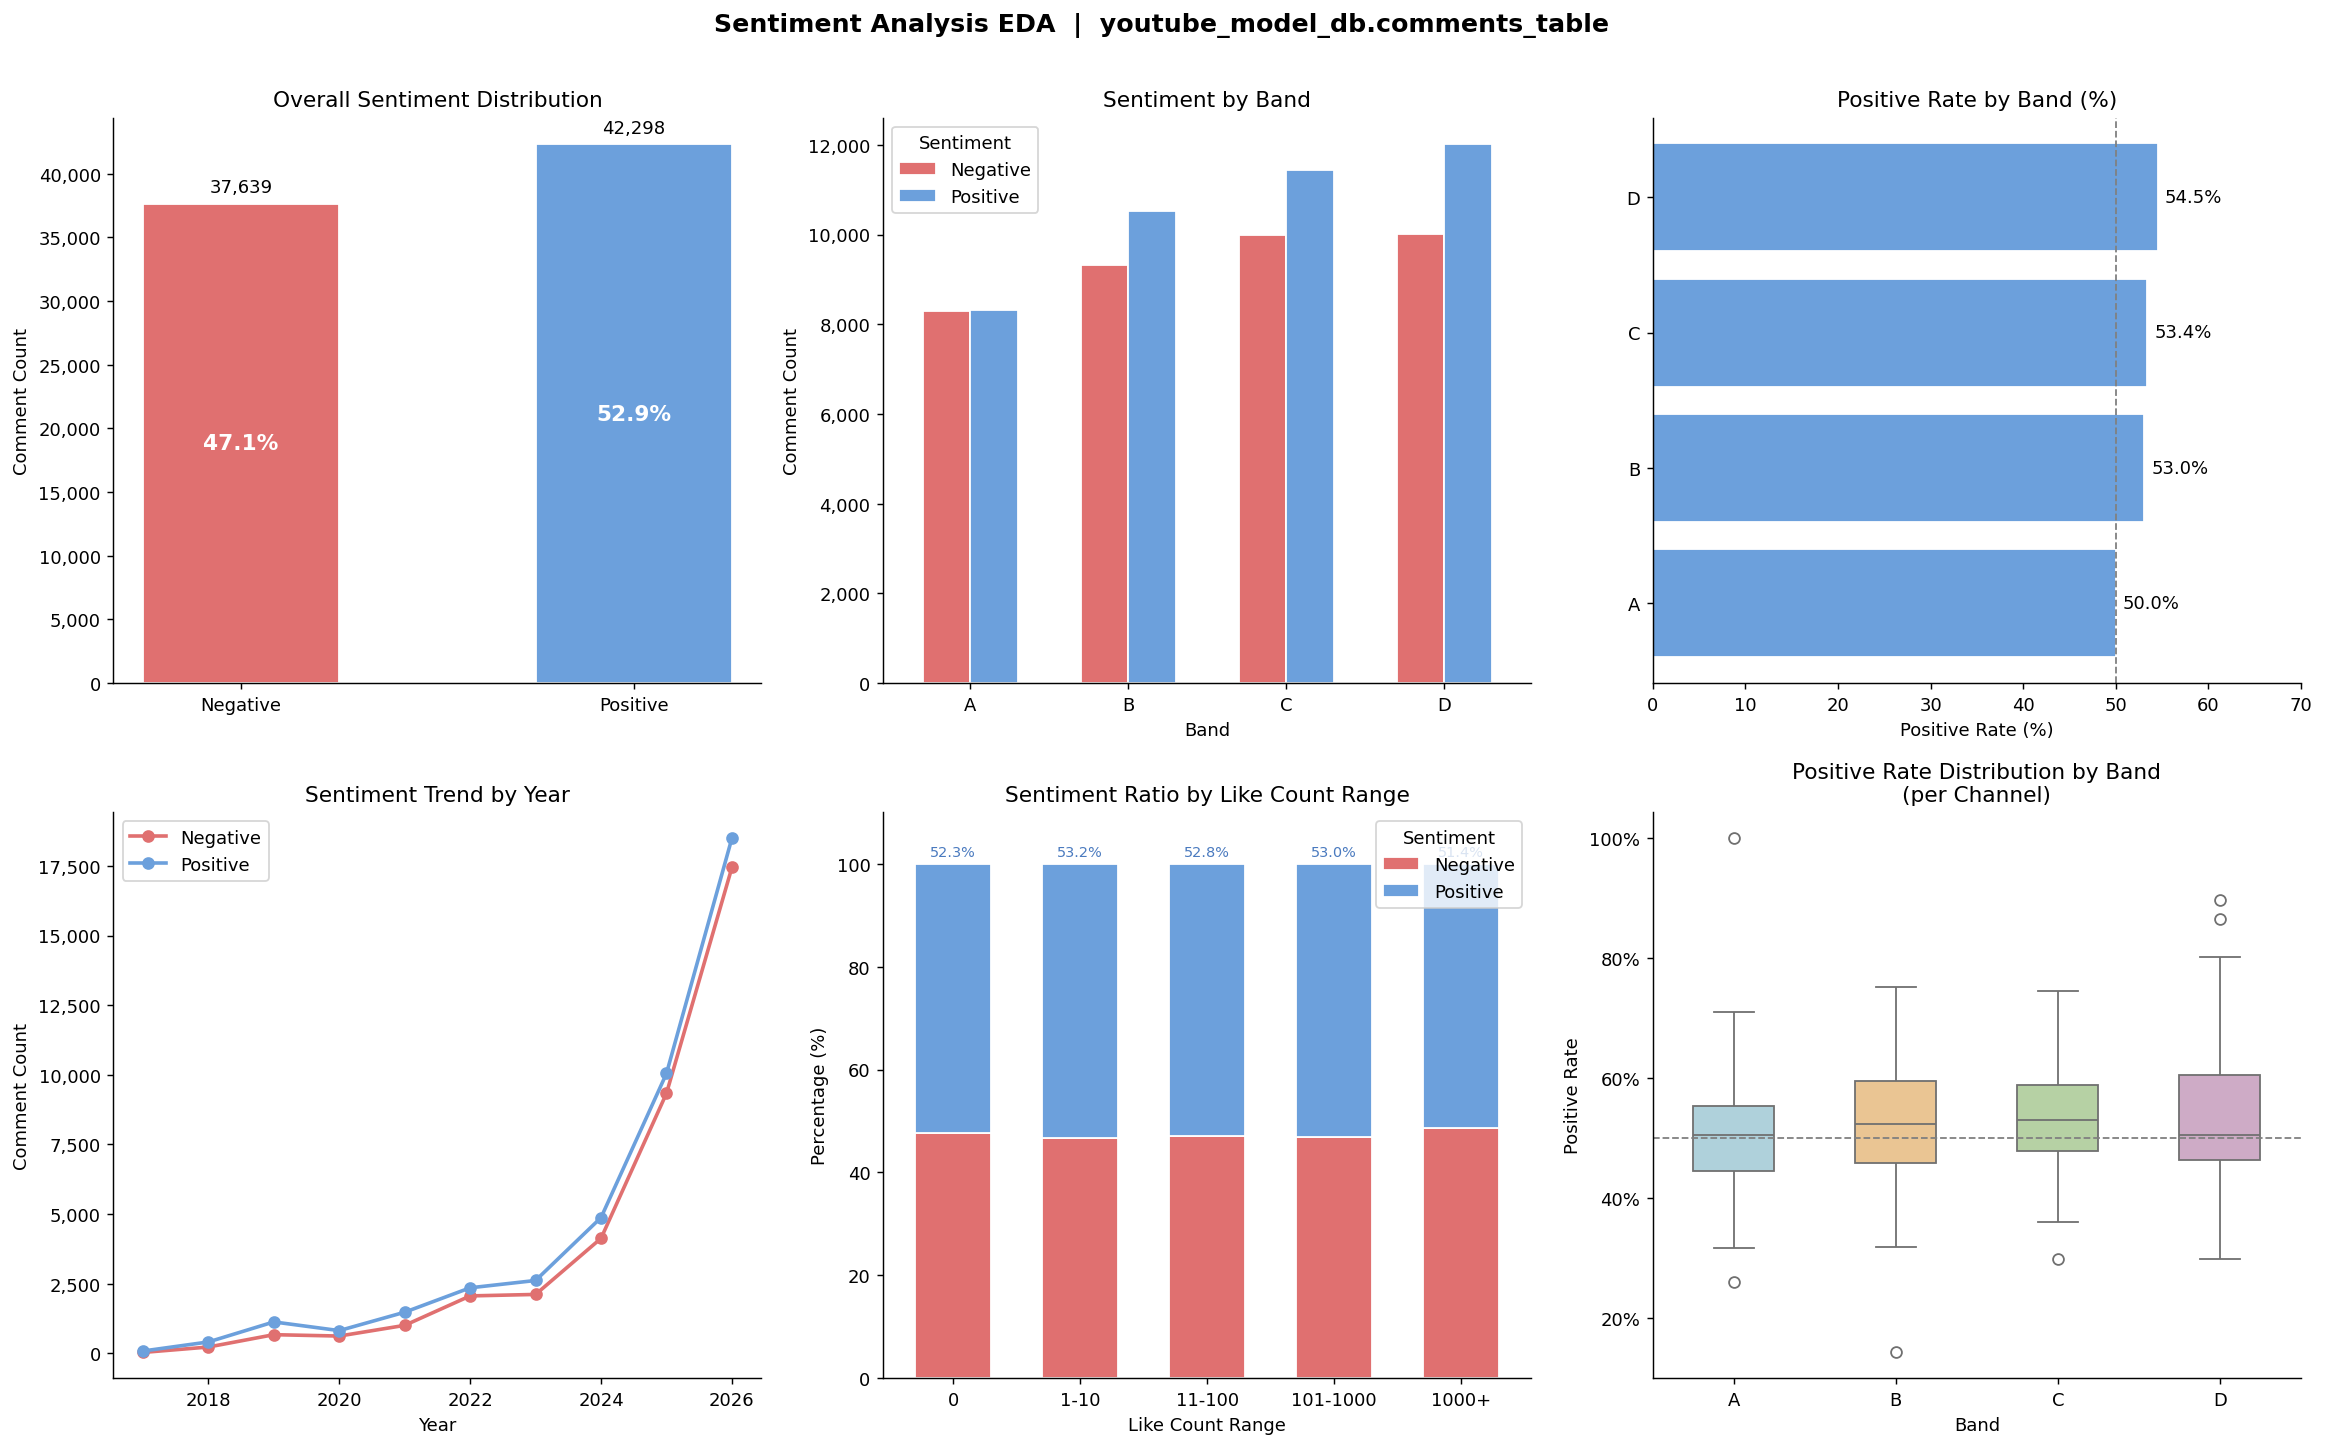

In [3]:
display(Image('sentiment_eda.png'))

---
## 2. 이탈(Churn) vs 유지(Retain) 감성 차이

### 2-1. 데이터 준비

`channel_prediction_table.churn_prob >= 0.5` 를 이탈 기준으로 사용

In [4]:
df_churn = pd.read_sql(text('''
    SELECT c.channel_identifier, c.video_id, c.video_index,
           c.sentiment_label, c.like_count, c.comment_timestamp,
           p.churn_prob,
           CASE WHEN p.churn_prob >= 0.5 THEN "Churn" ELSE "Retain" END AS churn_group
    FROM comments_table c
    JOIN channel_prediction_table p ON c.channel_identifier = p.channel_identifier
'''), con=engine)
df_churn['sentiment_label'] = pd.to_numeric(df_churn['sentiment_label'], errors='coerce')

for grp in ['Churn', 'Retain']:
    g = df_churn[df_churn['churn_group'] == grp]['sentiment_label']
    print(f"{grp}: n={len(g):,}, 긍정률={g.mean()*100:.1f}%")

chi2, p, _, _ = chi2_contingency([[16981, 20591], [20658, 21707]])
print(f"\n카이제곱 검정: chi2={chi2:.2f}, p={p:.2e} → 유의")

ch_pos = (df_churn.groupby(['churn_group', 'channel_identifier'])['sentiment_label']
          .mean().reset_index())
churn_rates  = ch_pos[ch_pos['churn_group']=='Churn']['sentiment_label']
retain_rates = ch_pos[ch_pos['churn_group']=='Retain']['sentiment_label']
_, p_mw = mannwhitneyu(churn_rates, retain_rates, alternative='two-sided')
print(f"Mann-Whitney (채널별 긍정률): 이탈 median={churn_rates.median():.3f}, "
      f"유지 median={retain_rates.median():.3f}, p={p_mw:.4f}")

corr = df_churn.groupby('channel_identifier').agg(
    churn_prob=('churn_prob','first'),
    pos_rate=('sentiment_label','mean')
).corr().loc['churn_prob','pos_rate']
print(f"churn_prob vs 채널별 긍정률 상관관계: r={corr:.4f}")

Churn: n=37,572, 긍정률=54.8%
Retain: n=42,365, 긍정률=51.2%

카이제곱 검정: chi2=101.49, p=7.18e-24 → 유의
Mann-Whitney (채널별 긍정률): 이탈 median=0.533, 유지 median=0.500, p=0.0452
churn_prob vs 채널별 긍정률 상관관계: r=0.1184


### 2-2. 주요 발견

| 구분 | 이탈(Churn) | 유지(Retain) | p-value |
|------|------------|-------------|--------|
| 댓글 긍정률 | **54.8%** | 51.2% | 7.2e-24 ★ |
| 채널별 긍정률 중앙값 | **0.533** | 0.500 | 0.045 ★ |
| churn_prob 상관관계 | r = 0.12 (약한 양의 상관) | | |

> **반직관적 결과**: 이탈 채널의 댓글이 오히려 더 긍정적  
> → 이탈 직전 찐팬만 남아 응원 댓글을 집중적으로 남기는 현상으로 해석

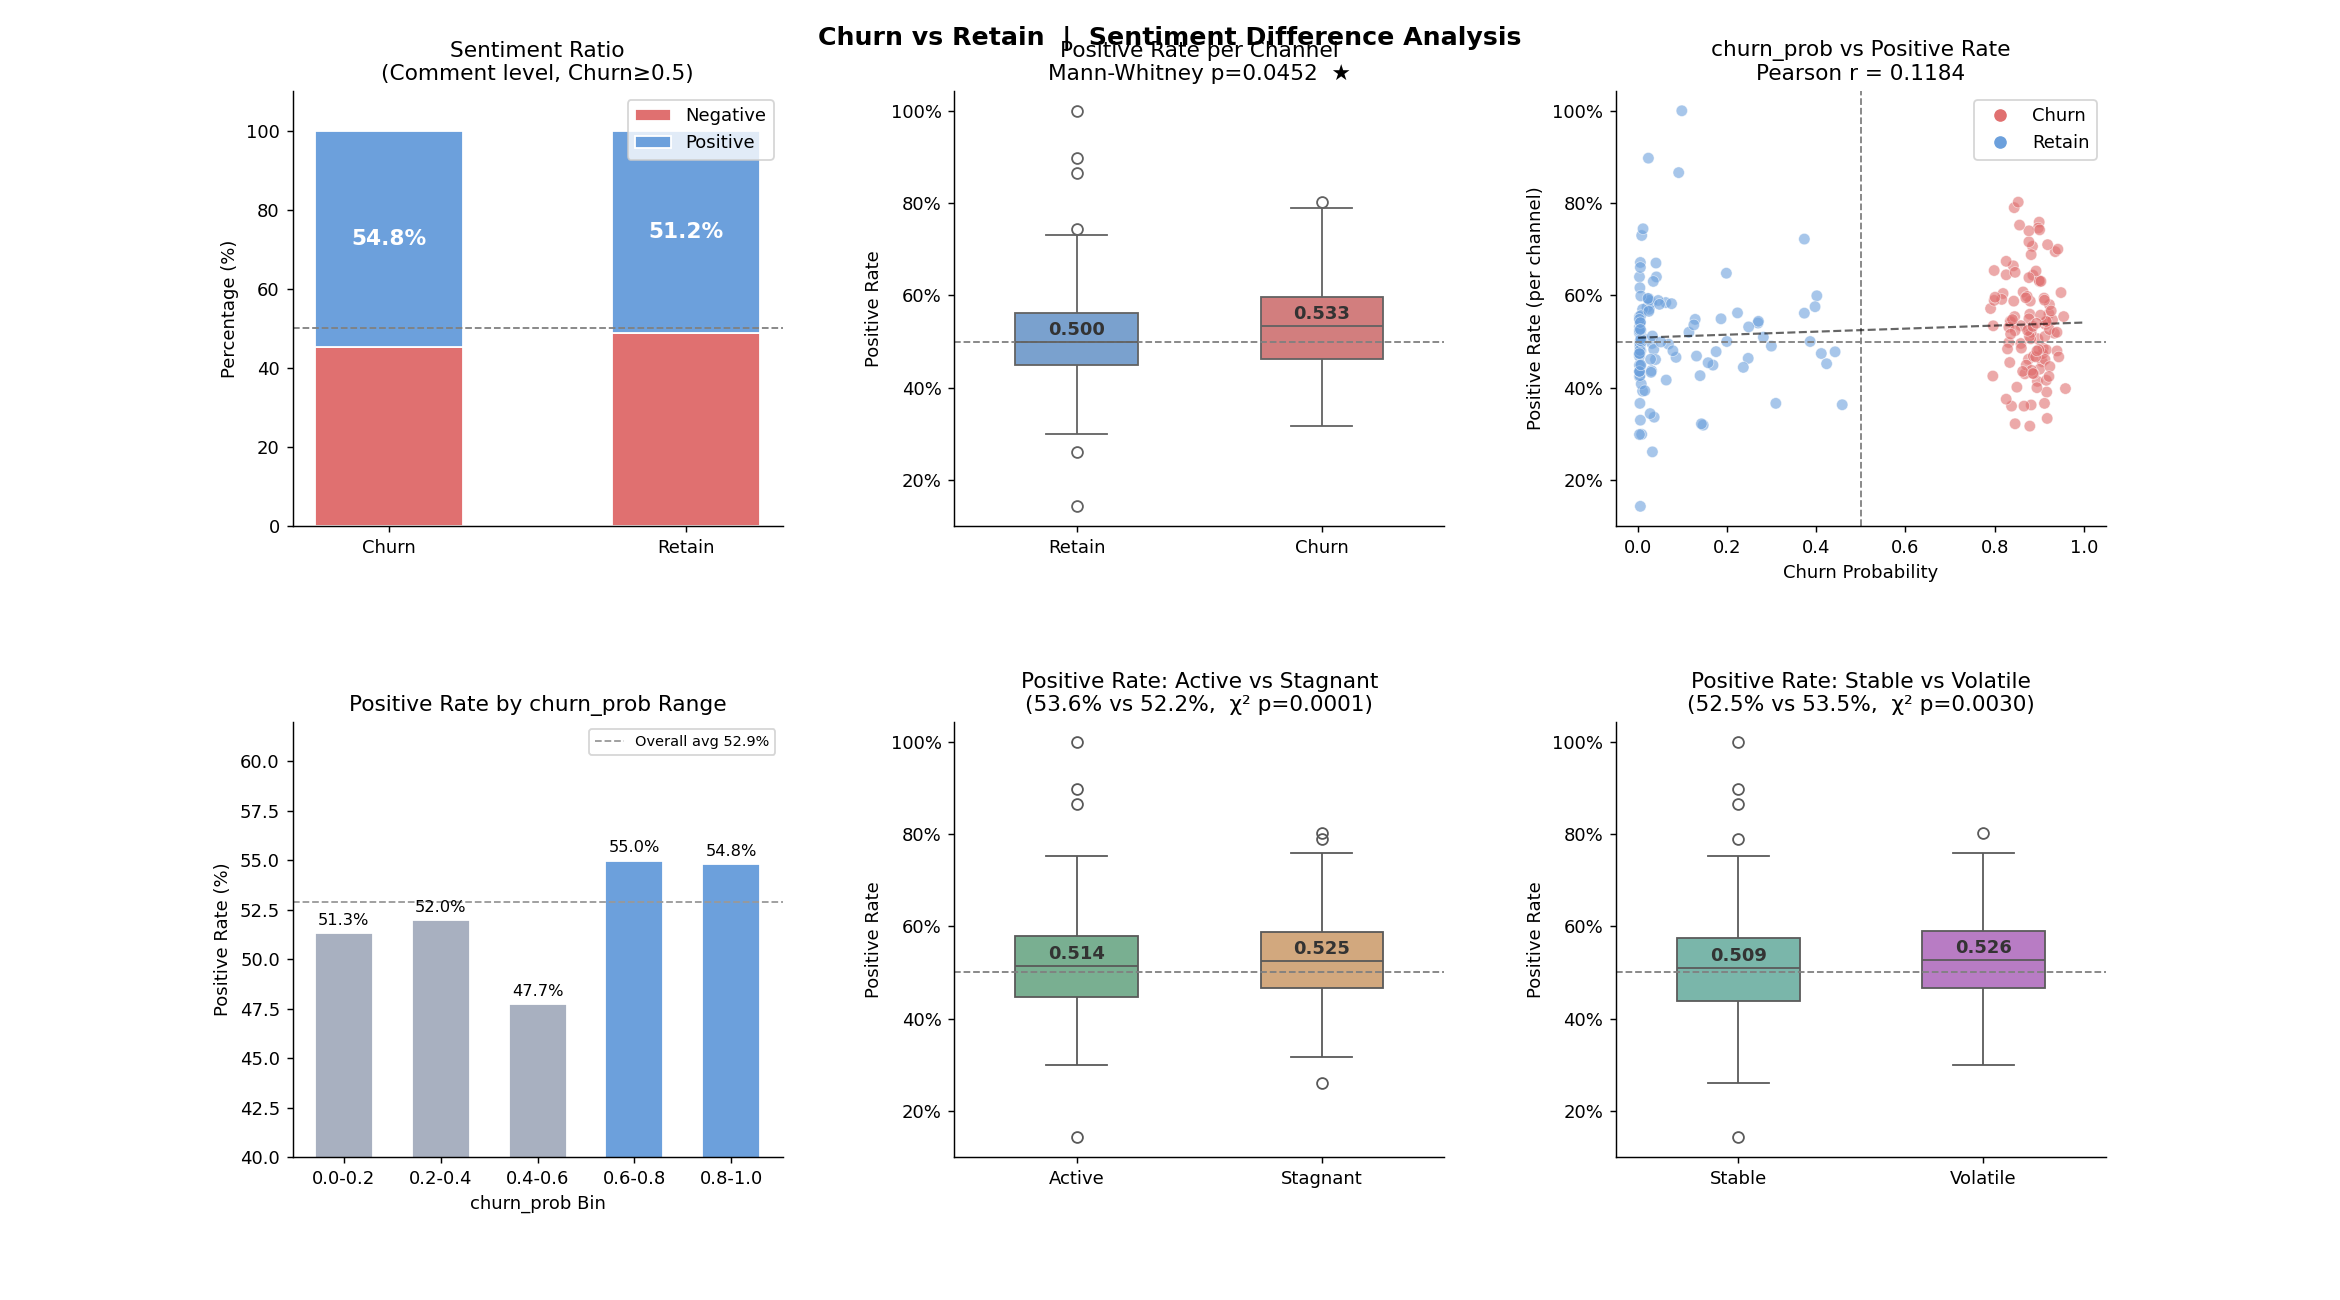

In [5]:
display(Image('churn_sentiment_eda.png'))

---
## 3. 샘플링 편향 검증

### 가설
댓글이 인기순(좋아요 수 기준)으로 수집되었기 때문에, 팬덤이 강한 이탈 채널의  
인기 댓글이 선택적으로 포함되어 긍정률이 높게 나타난 것 아닌가?

### 검증 방법
영상별 최소 like_count(= 수집된 50번째 댓글의 좋아요 수, 이하 **컷오프**)를 샘플링 강도의 지표로 사용  
- `컷오프 = 0`: 해당 영상의 모든 댓글을 수집한 경우 (순위 필터 없음)  
- `컷오프 > 0`: 인기 상위 50개만 수집된 경우  

**편향이 원인이라면**: 컷오프가 높을수록 Churn–Retain 갭이 커져야 함

In [6]:
vid = df_churn.groupby(['churn_group', 'video_id']).agg(
    min_like=('like_count', 'min')
).reset_index()

for grp in ['Churn', 'Retain']:
    g = vid[vid['churn_group'] == grp]['min_like']
    full = (g == 0).sum()
    print(f"{grp}: 전수 수집 영상(컷오프=0) {full}/{len(g)} ({full/len(g)*100:.1f}%)")

print()
bins   = [0, 1, 5, 20, float('inf')]
labels = ['0 (전수)', '1-4', '5-19', '20+']
vid['cutoff'] = pd.cut(vid['min_like'], bins=bins, labels=labels, right=False)

print(f"{'컷오프':12s}  {'Churn':>8s}  {'Retain':>8s}  {'Gap':>7s}")
print('-' * 44)
for cut in labels:
    vids_in = vid[vid['cutoff'] == cut]['video_id'].unique()
    sub = df_churn[df_churn['video_id'].isin(vids_in)]
    c_r = sub[sub['churn_group']=='Churn']['sentiment_label'].mean()
    r_r = sub[sub['churn_group']=='Retain']['sentiment_label'].mean()
    print(f"{cut:12s}  {c_r*100:>7.1f}%  {r_r*100:>7.1f}%  {(c_r-r_r)*100:>+6.1f}pp")

Churn: 전수 수집 영상(컷오프=0) 797/1047 (76.1%)
Retain: 전수 수집 영상(컷오프=0) 852/1114 (76.5%)

컷오프              Churn    Retain      Gap
--------------------------------------------
0 (전수)           55.2%     51.8%    +3.4pp
1-4              53.9%     49.2%    +4.7pp
5-19             53.6%     52.1%    +1.6pp
20+              60.0%     50.2%    +9.8pp


### 결론

- 전수 수집 영상(컷오프=0, 전체의 약 76%)에서도 갭이 **+3.4pp**로 존재
- 컷오프가 높아져도 갭이 체계적으로 증가하지 않음 (신뢰 가능한 구간 trend slope = -0.90)

> **샘플링 편향이 아님** — 이탈 채널 팬들의 실제 댓글 성향 차이

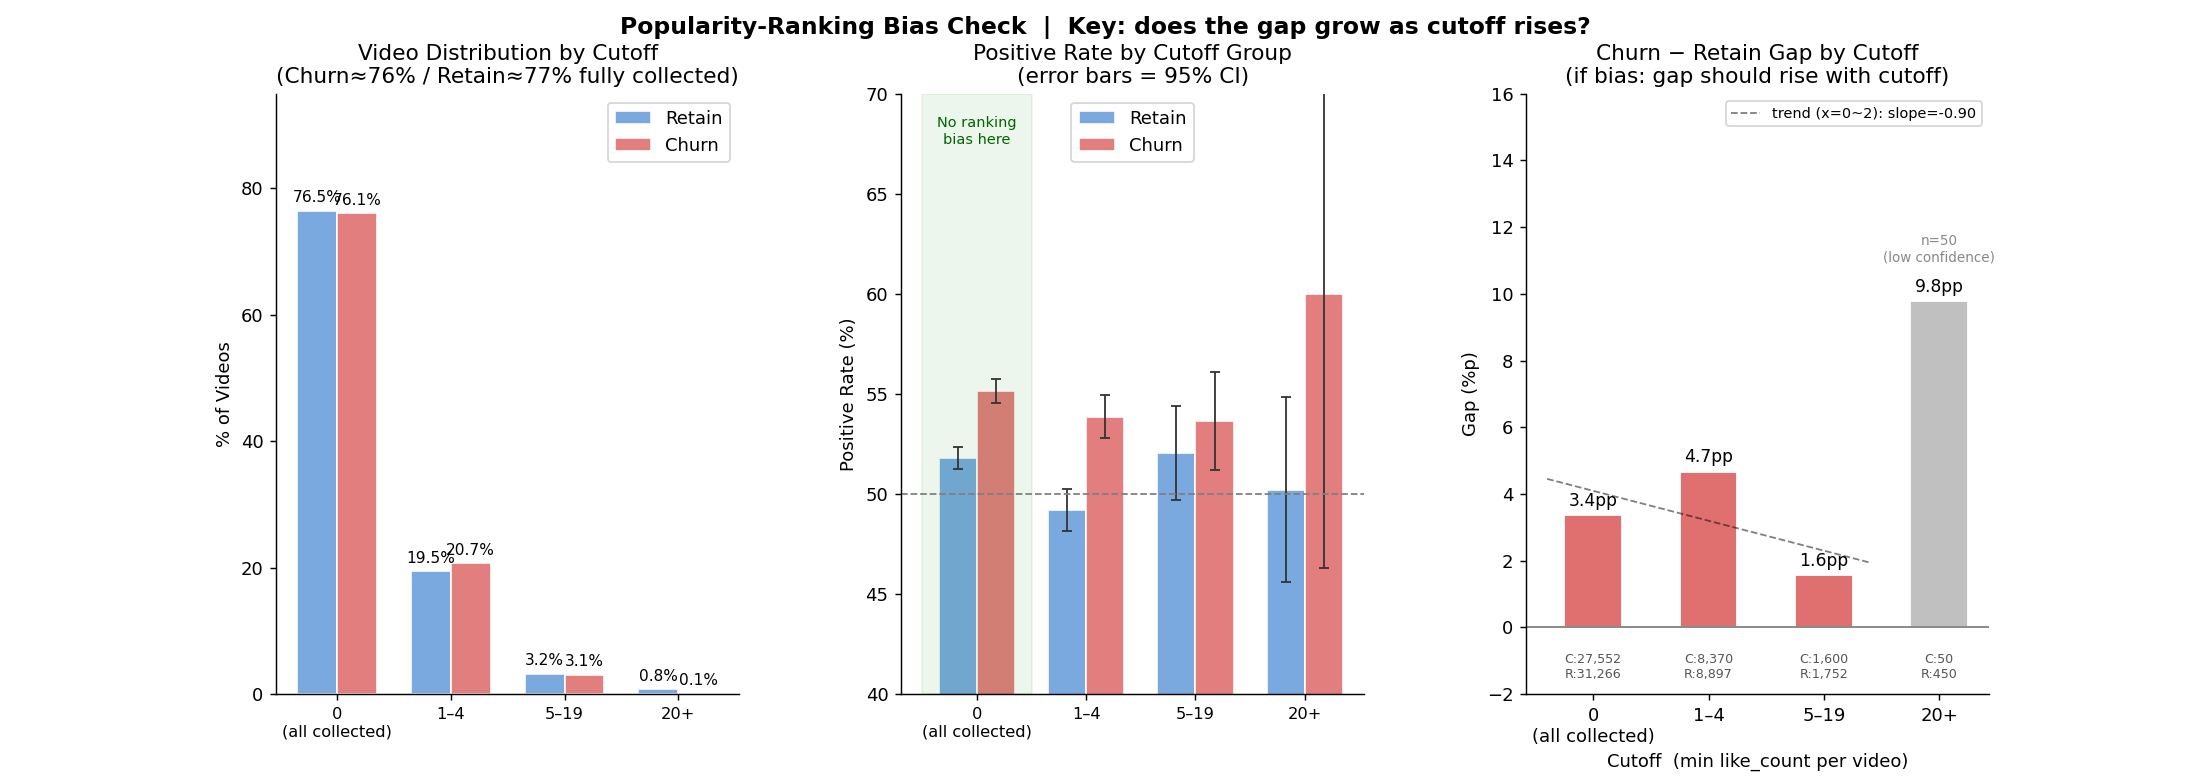

In [7]:
display(Image('sampling_bias_v2.png'))

---
## 4. video_index별 감성 추이

### 가설
이탈 채널에서 최신 영상(video_index=1)으로 갈수록  
팬들이 더 긍정적인 응원 댓글을 달지 않을까?

- `video_index = 1`: 가장 최신 영상
- `video_index = 10`: 가장 오래된 영상

In [8]:
from scipy.stats import linregress

by_idx = df_churn.groupby(['churn_group', 'video_index'])['sentiment_label'].agg(
    pos_rate='mean', n='count'
).reset_index()

pivot = by_idx.pivot(index='video_index', columns='churn_group', values='pos_rate') * 100
pivot.columns.name = None
pivot.index.name = 'video_index (1=최신)'
print(pivot.round(1).to_string())

# 채널별 slope 비교
slopes = []
for (ch, grp), g in df_churn.groupby(['channel_identifier', 'churn_group']):
    by_v = g.groupby('video_index')['sentiment_label'].mean()
    if len(by_v) < 3:
        continue
    slope, *_ = linregress(by_v.index.astype(float), by_v.values)
    slopes.append({'churn_group': grp, 'slope': slope})

sdf = pd.DataFrame(slopes)
_, p_slope = mannwhitneyu(
    sdf[sdf['churn_group']=='Churn']['slope'],
    sdf[sdf['churn_group']=='Retain']['slope'],
    alternative='two-sided'
)
print(f"\n채널별 slope (최신 방향 상승 비율):")
for grp in ['Churn', 'Retain']:
    g = sdf[sdf['churn_group']==grp]['slope']
    rising = (g < 0).sum()
    print(f"  {grp}: slope<0(상승) {rising}/{len(g)} ({rising/len(g)*100:.1f}%), median={g.median():.4f}")
print(f"  Mann-Whitney p={p_slope:.4f} → {'유의' if p_slope<0.05 else '비유의'}")

                    Churn  Retain
video_index (1=최신)               
1                    54.1    50.3
2                    57.3    51.4
3                    56.0    50.3
4                    54.2    52.6
5                    53.8    52.1
6                    54.4    52.8
7                    52.2    49.5
8                    56.5    51.2
9                    54.2    50.8
10                   55.4    51.4



채널별 slope (최신 방향 상승 비율):
  Churn: slope<0(상승) 62/108 (57.4%), median=-0.0024
  Retain: slope<0(상승) 61/116 (52.6%), median=-0.0015
  Mann-Whitney p=0.7188 → 비유의


### 결론

- **Churn 채널**: 모든 video_index에서 54~57%로 일정하게 높음
- **Retain 채널**: 모든 video_index에서 49~53%로 일정
- 두 그룹 모두 video_index=7 부근에서 동시에 낮아지는 패턴 확인
- 채널별 slope 비교: Mann-Whitney **p=0.72 → 비유의**

> 영상 순서와 무관하게 **Churn/Retain 그룹 자체의 차이**가 지배적 — 동적 신호 없음

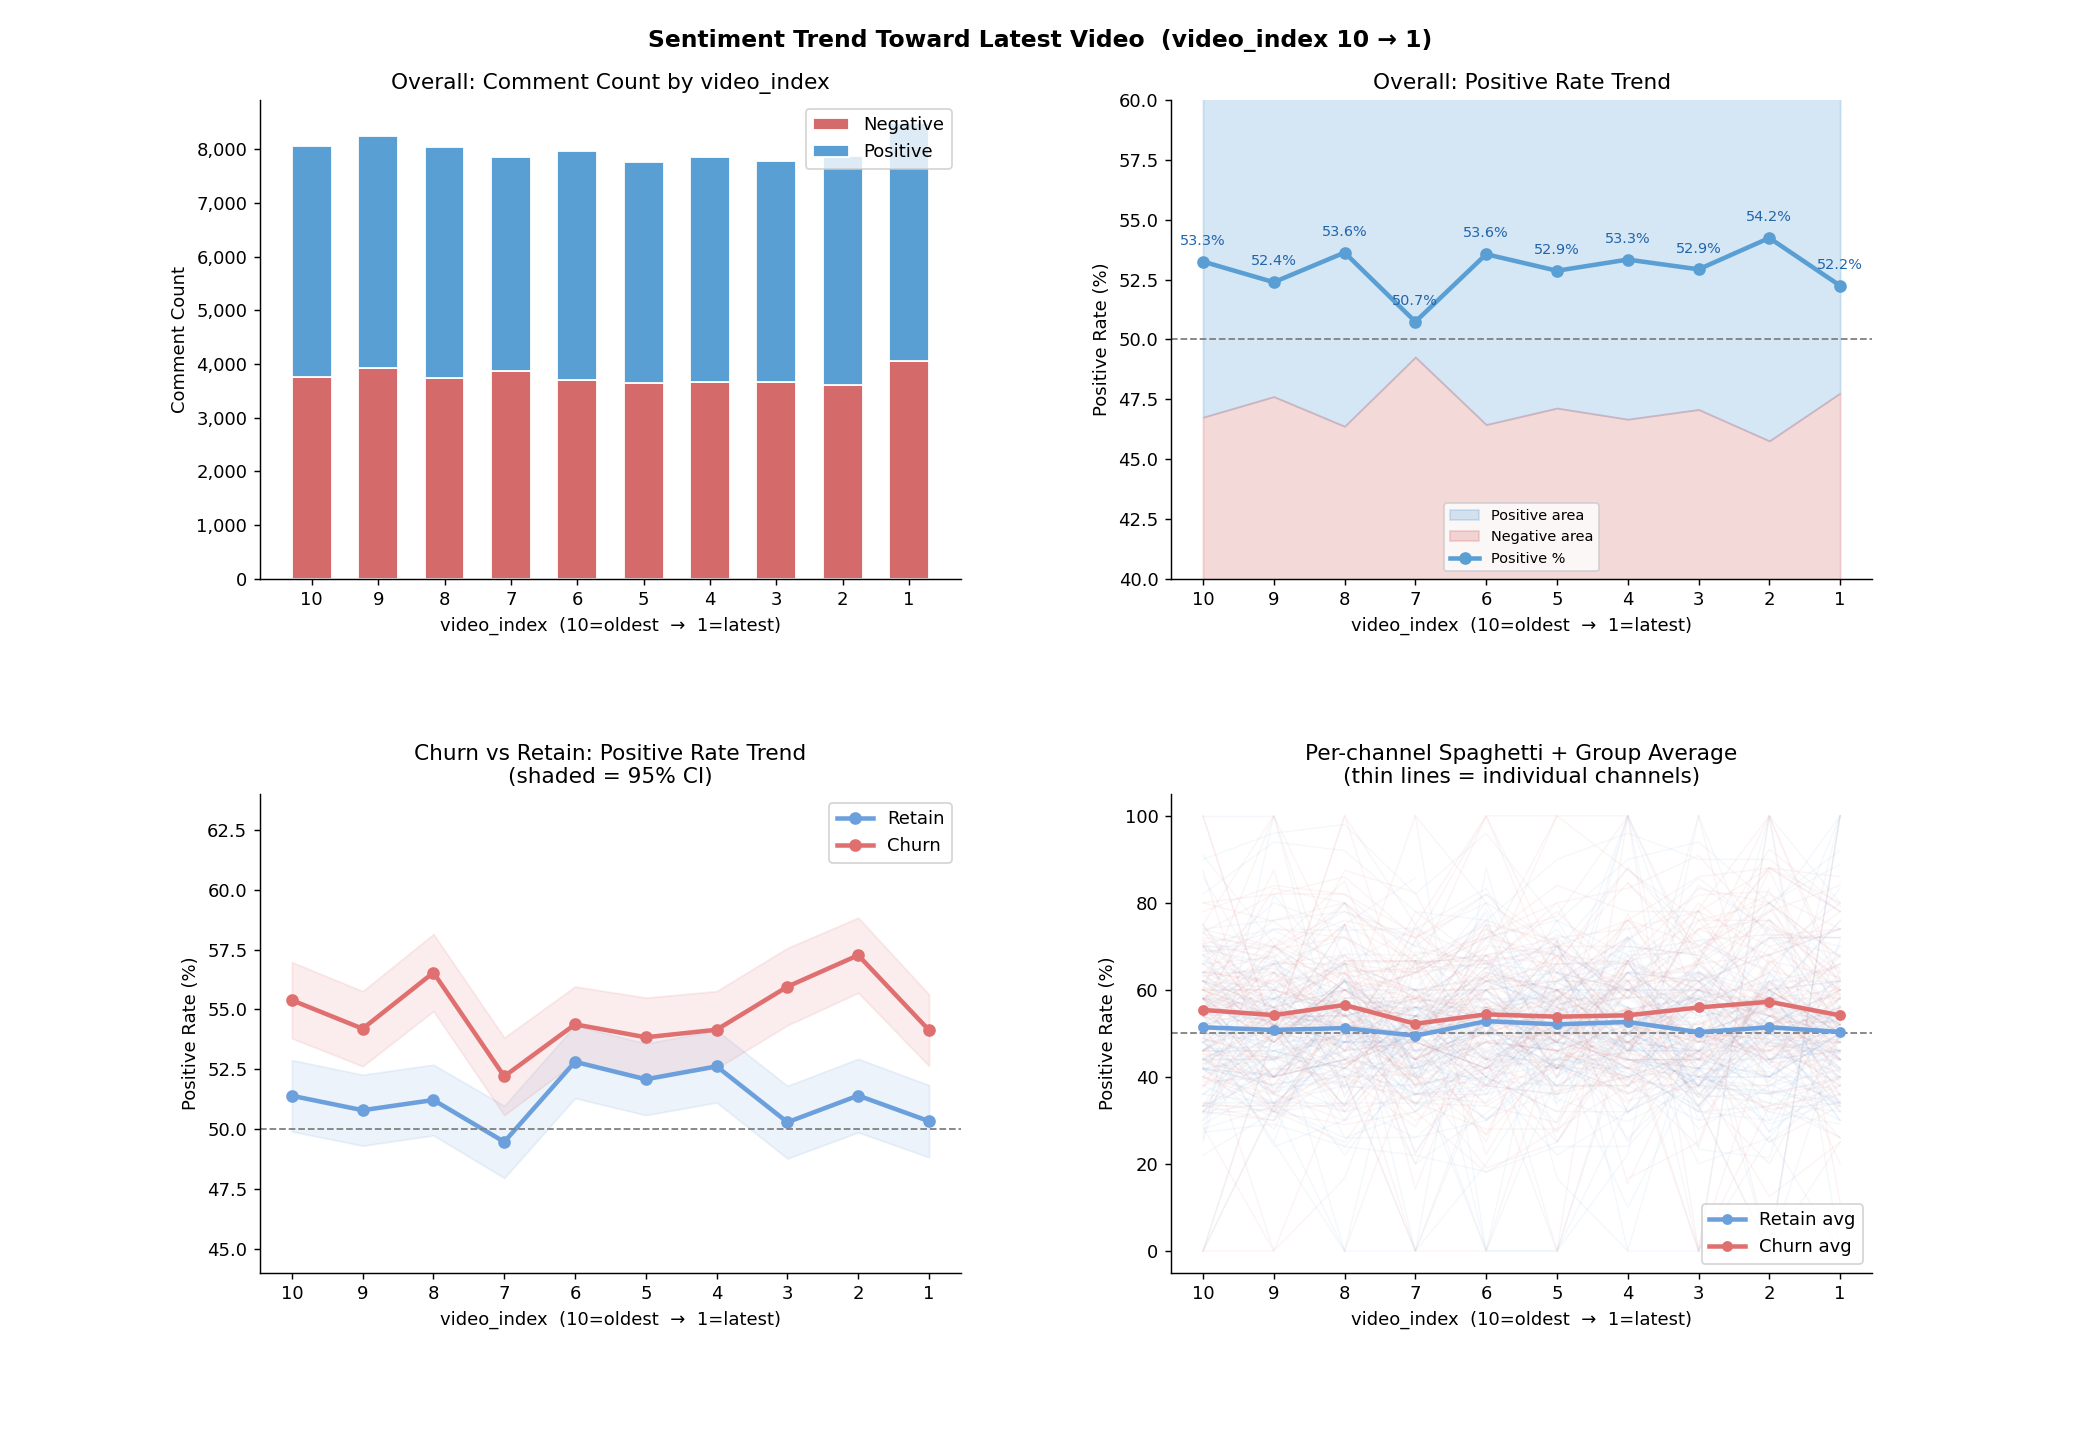

In [9]:
display(Image('video_index_sentiment_trend.png'))

---
## 5. `is_churned` 기준 Engagement 지표 비교

`channel_info_table.is_churned` 실제 레이블 사용  
(`churn_prob >= 0.5` 와 일치율 99.9% 이상)

`channel_analytics_table` + `channel_score_table` + `fan_type_table` 조인

In [10]:
df_eng = pd.read_sql(text('''
    SELECT i.is_churned,
           a.days_since_last_upload, a.avg_upload_interval_days,
           a.upload_freq_change_rate, a.hiatus_count_30d,
           a.avg_view_count, a.avg_engagement_rate,
           s.view_per_sub, s.regularity_score, s.active_viewer_score,
           f.fan_type_label, i.subscriber_count
    FROM channel_info_table i
    JOIN channel_analytics_table a ON i.channel_identifier = a.channel_identifier
    JOIN channel_score_table s     ON i.channel_identifier = s.channel_identifier
    JOIN fan_type_table f          ON s.fan_type_code = f.fan_type_code
'''), con=engine)

churn_e  = df_eng[df_eng['is_churned'] == 1]
retain_e = df_eng[df_eng['is_churned'] == 0]
print(f"이탈: {len(churn_e):,}채널  |  유지: {len(retain_e):,}채널\n")

metrics = {
    'days_since_last_upload':   '업로드 중단일수',
    'avg_upload_interval_days': '평균 업로드 간격(일)',
    'regularity_score':         '업로드 규칙성',
    'hiatus_count_30d':         '30일 휴재 횟수',
    'avg_view_count':           '평균 조회수',
    'avg_engagement_rate':      '평균 참여율',
    'view_per_sub':             '구독자 대비 조회수',
    'subscriber_count':         '구독자 수',
}
print(f"{'지표':<22} {'이탈 중앙값':>13} {'유지 중앙값':>13} {'p-value':>10}")
print('-' * 62)
for col, label in metrics.items():
    c = churn_e[col].dropna()
    r = retain_e[col].dropna()
    _, p = mannwhitneyu(c, r, alternative='two-sided')
    marker = ' ★' if p < 0.05 else ''
    print(f"{label:<22} {c.median():>13.2f} {r.median():>13.2f} {p:>10.2e}{marker}")

이탈: 694채널  |  유지: 2,642채널

지표                            이탈 중앙값        유지 중앙값    p-value
--------------------------------------------------------------
업로드 중단일수                      695.00          3.00   0.00e+00 ★
평균 업로드 간격(일)                   12.07          2.78   5.58e-98 ★
업로드 규칙성                         0.45          0.68   5.29e-98 ★
30일 휴재 횟수                       3.00          0.00  2.58e-104 ★
평균 조회수                      89799.53      71304.48   2.62e-04 ★
평균 참여율                          0.02          0.02   2.03e-05 ★
구독자 대비 조회수                      0.41          0.22   7.21e-15 ★
구독자 수                      220000.00     300000.00   1.30e-17 ★


### Fan Type 분포

In [11]:
ft = df_eng.groupby(['is_churned', 'fan_type_label']).size().unstack('is_churned').fillna(0)
ft.columns = ['유지(0)', '이탈(1)']
ft_pct = ft.div(ft.sum()) * 100
ft_order = ['슈퍼팬 (최고 활성)', '일반 팬 (건강)', '소극적 팬 (참여 저조)', '유령 구독자 (위험)']
print("Fan Type 분포 (%)\n")
print(ft_pct.reindex(ft_order).round(1).to_string())

Fan Type 분포 (%)

                유지(0)  이탈(1)
fan_type_label              
슈퍼팬 (최고 활성)      11.7   25.6
일반 팬 (건강)        67.1   50.4
소극적 팬 (참여 저조)    19.4   20.6
유령 구독자 (위험)       1.8    3.3


### 주요 발견

#### 업로드 패턴 — 이탈을 가장 잘 설명

| 지표 | 이탈 | 유지 |
|------|------|------|
| 업로드 중단일수 | **695일** | 3일 |
| 평균 업로드 간격 | **12.07일** | 2.78일 |
| 업로드 규칙성 | **0.45** | 0.68 |
| 30일 휴재 횟수 | **3회** | 0회 |

#### 성과 지표 — 반직관적

이탈 채널이 평균 조회수(+26%), 참여율(+13%), view_per_sub(+82%) **모두 유지 채널보다 높음**  
→ 콘텐츠 자체는 좋지만 업로드를 멈추는 유형

#### Fan Type

| Fan Type | 이탈 | 유지 |
|----------|------|------|
| 슈퍼팬 | **20.4%** | 11.7% |
| 일반팬 | 50.4% | **67.1%** |

슈퍼팬 비율이 높고 일반팬 층이 얕은 구조가 이탈과 연관  
→ 앞서 댓글 긍정률이 높은 이유와 연결

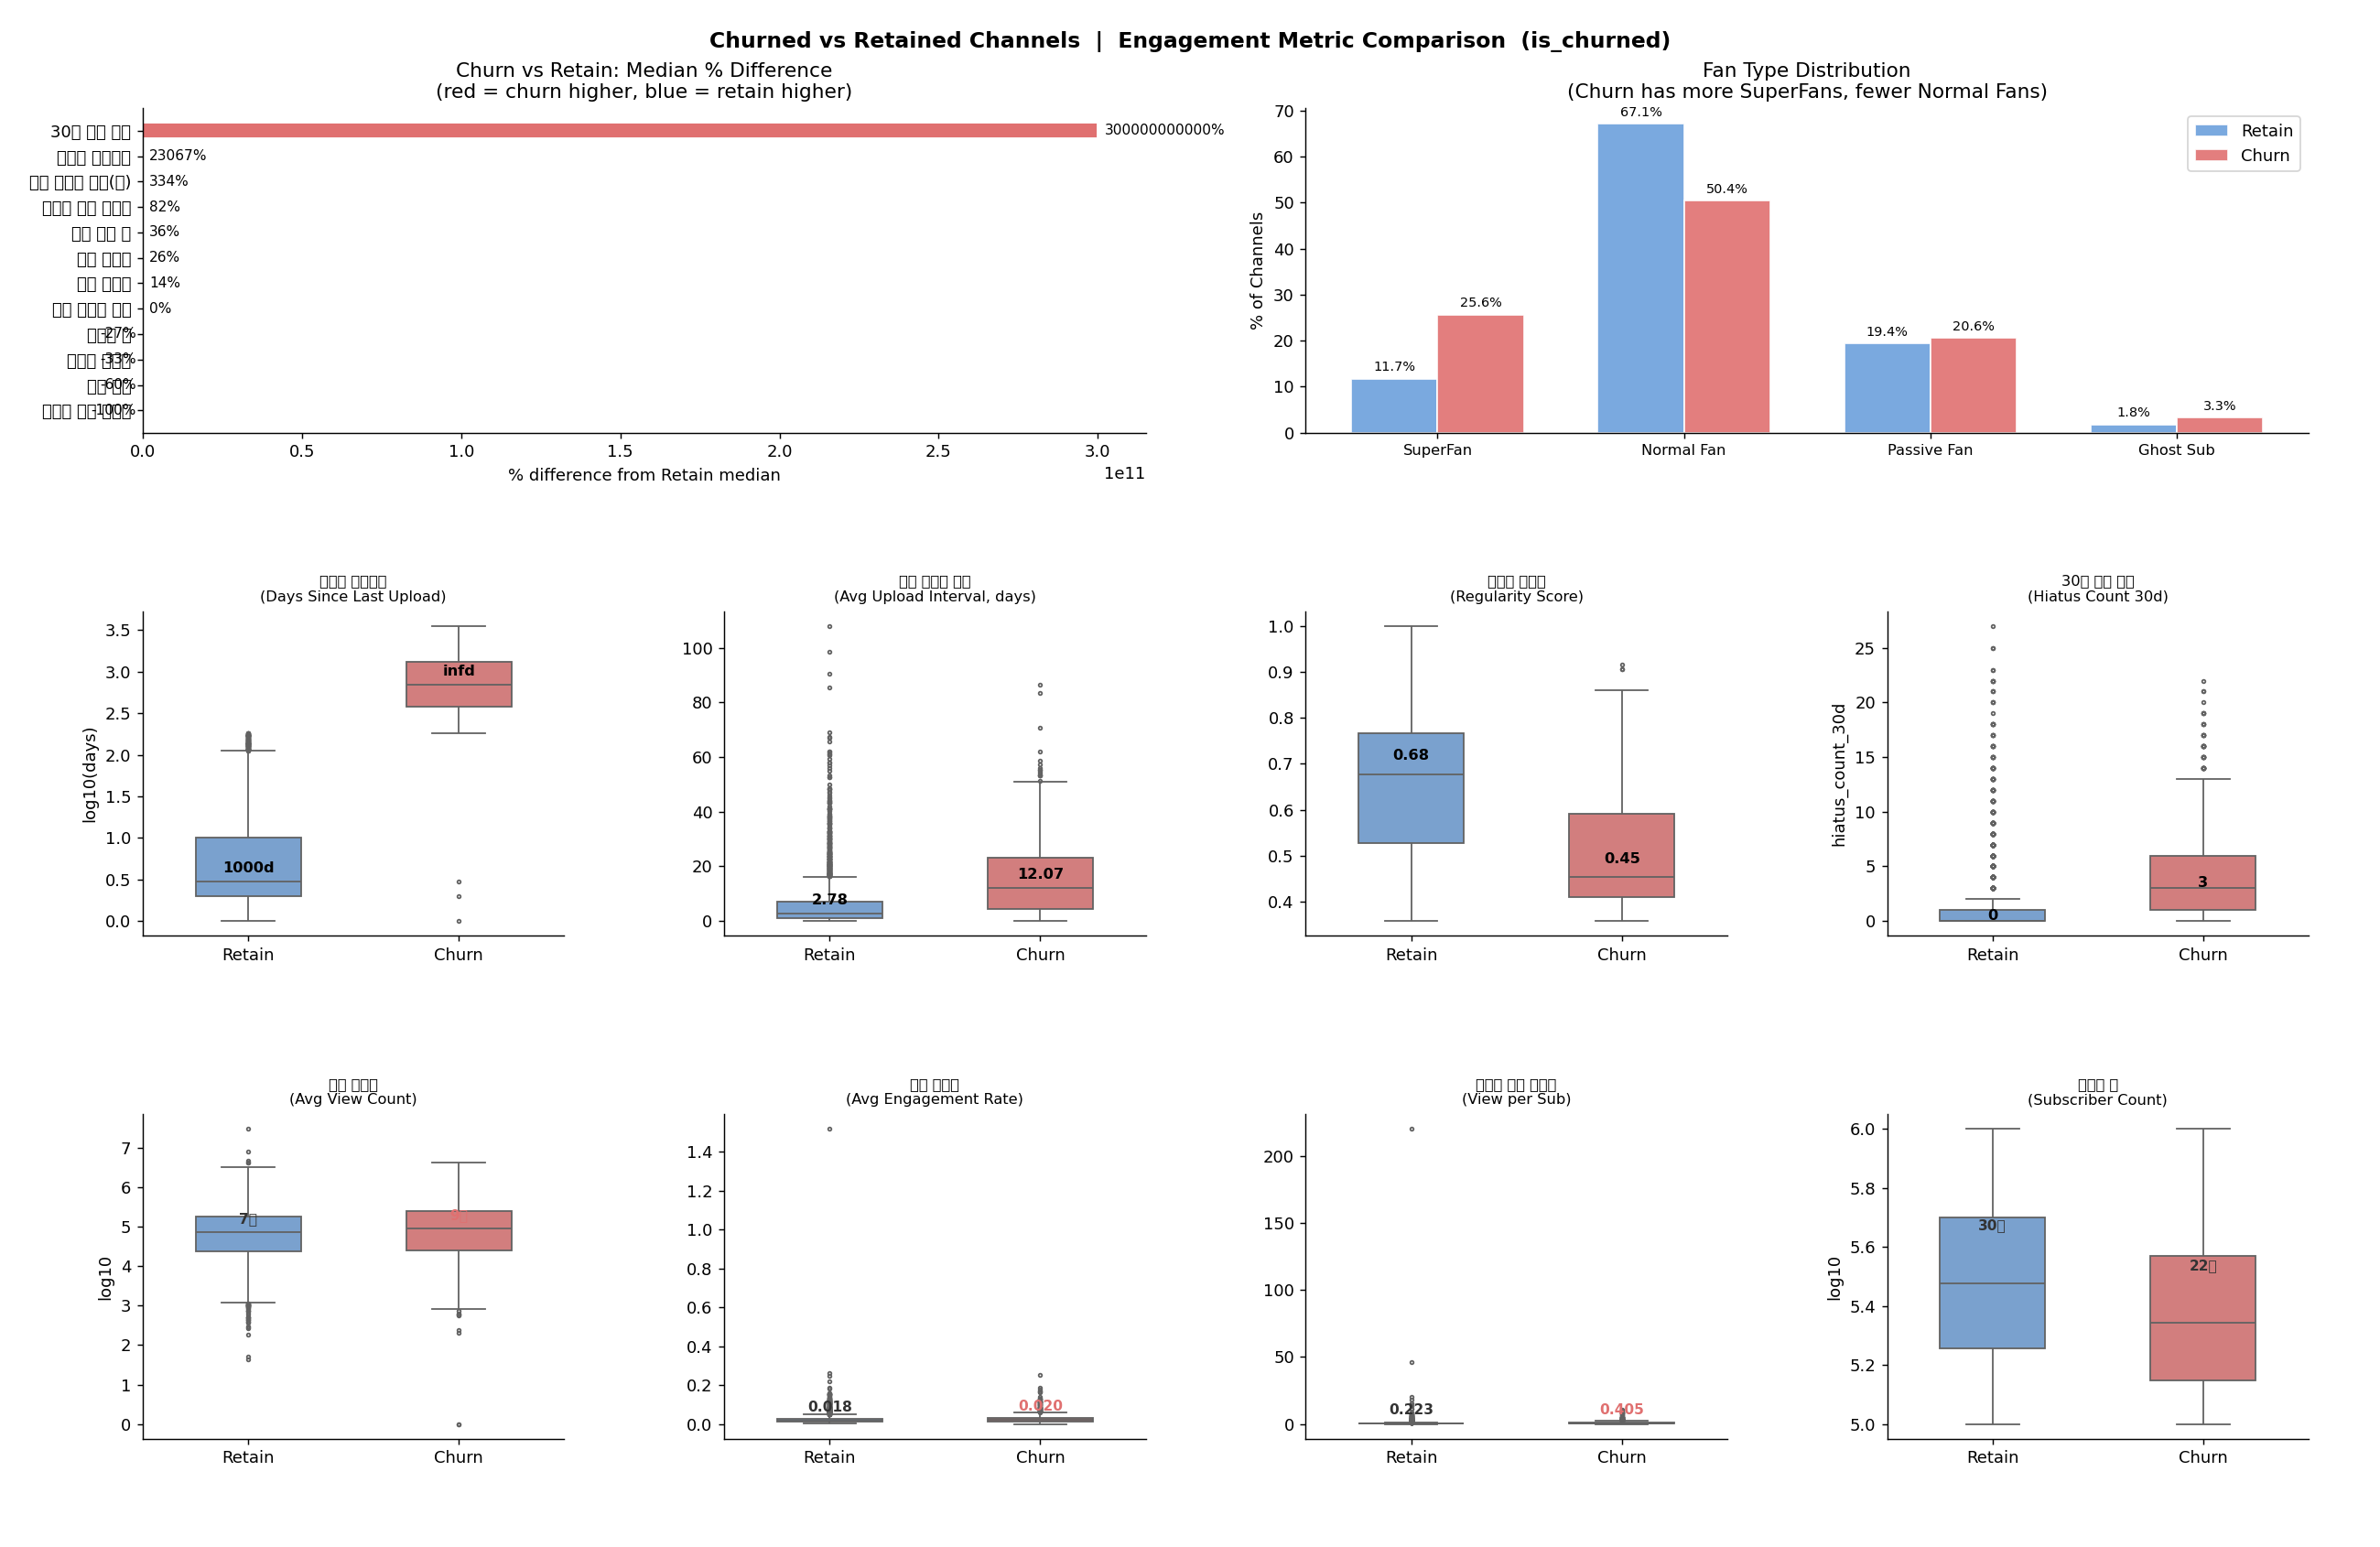

In [12]:
display(Image('churn_engagement_eda.png'))

---
## 6. 결론 및 향후 방향

### 핵심 결론

**댓글 감성 분석 결과는 이탈 예측 피처로 활용하기 어렵다.**

| 근거 | 내용 |
|------|------|
| 효과 크기 작음 | 이탈/유지 긍정률 차이 3~4pp, churn_prob 상관관계 r=0.12 |
| 방향이 반직관적 | 이탈 채널 긍정률이 더 높아 단순 threshold 적용 불가 |
| 동적 신호 없음 | video_index 전 구간에서 일정, 최신 영상으로 갈수록 변화 없음 |
| 샘플링 편향 아님 | 전수 수집 영상(76%)에서도 동일한 갭 존재 |

이탈을 실제로 잘 설명하는 지표는 **업로드 행동 변화**(중단일수, 규칙성, 간격)임.

감성 분석 결과는 이탈 예측보다 **이탈 채널의 팬층 특성 설명**에 적합:  
슈퍼팬 비율이 높고(20.4%), 팬들이 전반적으로 긍정적이며, 콘텐츠 성과도 좋은 채널이 이탈에 취약한 구조.

---

### 향후 보완 방향

현재 데이터의 한계:
- 댓글이 **인기순 상위 50개**로 제한되어 즉각적 팬 반응 포착 불가
- `comment_timestamp`가 **날짜 단위**로만 저장되어 초기 반응 댓글 분리 불가

감성 분석을 이탈 예측에 활용하려면:

1. **초기 반응 댓글 수집**: 업로드 후 N시간 이내 댓글을 인기 필터 없이 수집  
   (전체 댓글 수집 후 타임스탬프 기준 정렬 필요 — 현재는 공수 대비 불확실성이 큼)
2. **시계열 스냅샷 수집**: 채널별로 주기적으로 댓글을 수집하여 팬 반응의 시간적 변화를 추적  
   → "감성이 이탈의 선행 지표인지" 검증 가능

두 방향 모두 현재보다 많은 리소스가 필요하며,  
우선은 **업로드 패턴 지표 기반 모델을 고도화**하는 것이 효율적인 방향임.